<a href="https://colab.research.google.com/github/f1212park20/React-MongoDB/blob/main/2021_%EA%B0%80%EA%B2%8C%EC%A7%80%EC%B6%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
from google.colab import files
uploaded = files.upload()


Saving 항목별_월간_평균_소비지출_20240928150355.xlsx to 항목별_월간_평균_소비지출_20240928150355 (2).xlsx


In [53]:
import pandas as pd
import warnings
from IPython.display import HTML
import matplotlib.pyplot as plt
import seaborn as sns


warnings.simplefilter("ignore")

workbook=pd.read_excel('항목별_월간_평균_소비지출_20240928150355.xlsx')
# print(workbook)
print()

# 나이별로 데이터 분리
elementary = workbook[workbook['특성별(2)'].isin(['40대 이하', '50대', '60대', '70대', '80대 이상'])]
# print(elementary)

# 컬럼 이름 확인
# print(workbook.columns)

# 널값  확인후 학교급별로 변경
elementary.rename(columns={'2021' : '전체' }, inplace=True)
elementary.rename(columns={'2021.1' : '식료품비(외식비 포함)' }, inplace=True)
elementary.rename(columns={'2021.2' : '주거비' }, inplace=True)
elementary.rename(columns={'2021.3' : '교육(보육)비' }, inplace=True)
elementary.rename(columns={'2021.4' : '의료비' }, inplace=True)
elementary.rename(columns={'2021.5' : '교통비' }, inplace=True)
elementary.rename(columns={'2021.6' : '통신비' }, inplace=True)
elementary.rename(columns={'2021.7' : '기타 소비지출' }, inplace=True)
print(elementary)

# 널값  확인후 학교급별로 변경
# print(elementary.isnull().sum())
# print()

elementary['특성별(1)']='연령대별'
print(elementary)

# 표로 만들기
HTML(elementary.to_html())

# 공통 지출 순위
# 1.식료품비(외식비 포함)


  특성별(1)  특성별(2)     전체 식료품비(외식비 포함)   주거비 교육(보육)비   의료비   교통비   통신비 기타 소비지출
4   연령대별  40대 이하  274.5         93.9  32.4    33.4  13.6  30.6  17.7    52.9
5    NaN     50대  288.1         97.9  32.1    27.2  20.5  32.8    19    58.8
6    NaN     60대  213.1         82.5    27     3.8  19.6  24.6  12.4    43.3
7    NaN     70대  171.1         70.7  23.2     3.1  19.9  15.7   8.9    29.7
8    NaN  80대 이상  161.7         64.1    23     3.7  23.5  12.8   7.9    26.6
  특성별(1)  특성별(2)     전체 식료품비(외식비 포함)   주거비 교육(보육)비   의료비   교통비   통신비 기타 소비지출
4   연령대별  40대 이하  274.5         93.9  32.4    33.4  13.6  30.6  17.7    52.9
5   연령대별     50대  288.1         97.9  32.1    27.2  20.5  32.8    19    58.8
6   연령대별     60대  213.1         82.5    27     3.8  19.6  24.6  12.4    43.3
7   연령대별     70대  171.1         70.7  23.2     3.1  19.9  15.7   8.9    29.7
8   연령대별  80대 이상  161.7         64.1    23     3.7  23.5  12.8   7.9    26.6


,특성별(1),특성별(2),전체,식료품비(외식비 포함),주거비,교육(보육)비,의료비,교통비,통신비,기타 소비지출
4,연령대별,40대 이하,274.5,93.9,32.4,33.4,13.6,30.6,17.7,52.9
5,연령대별,50대,288.1,97.9,32.1,27.2,20.5,32.8,19,58.8
6,연령대별,60대,213.1,82.5,27,3.8,19.6,24.6,12.4,43.3
7,연령대별,70대,171.1,70.7,23.2,3.1,19.9,15.7,8.9,29.7
8,연령대별,80대 이상,161.7,64.1,23,3.7,23.5,12.8,7.9,26.6


4    17.7
5      19
6    12.4
7     8.9
8     7.9
Name: 통신비, dtype: object
4    17.7
5      19
6    12.4
7     8.9
8     7.9
Name: 통신비, dtype: object
   특성별(2)   통신비
4  40대 이하  17.7
5     50대    19
6     60대  12.4
7     70대   8.9
8  80대 이상   7.9


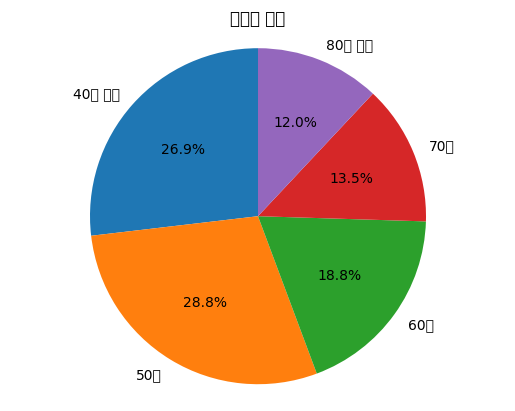

In [66]:
# 연령별 통신비 비교
charge=elementary['통신비']
print(charge)

a=elementary['특성별(2)']
print(charge)

# 데이터 프레임으로  변환
sample_df = pd.DataFrame({'특성별(2)': a, '통신비': charge, })
print(sample_df)

# 원형 차트 그리기
plt.pie(sample_df['통신비'], labels=sample_df['특성별(2)'], autopct='%1.1f%%', startangle=90)
plt.title('통신비 비율')
plt.axis('equal')  # 원형 유지
plt.show()

# 40대 이하 에서 통신비가 높은 이유
# 1) OTT 서비스 등 데이터를 많이 소비하는 서비스를 활발하게 이용하는 경향이 있습니다.
# 2) 최신 스마트폰 선호: 최신 스마트폰은 고성능 카메라, 고화질 디스플레이 등을 탑재하여 데이터 사용량이 증가하는 요인으로 작용합니다.
# 3) 데이터 무제한 요금제 선호: 40대 이하 연령층은 데이터 무제한 요금제를 선호하는 경향이 높아 상대적으로 통신비 비중이 높게 나타날 수 있습니다.
# 50대가 통신비가 높은 이유
# 1)자녀 스마트폰 요금 부담: 자녀들의 스마트폰 요금을 부담하는 경우가 많아 통신비 지출이 증가할 수 있습니다.
# 2)디지털 기기 활용도 증가: 과거에 비해 스마트폰 사용이 일반화되면서 50대의 스마트폰 이용률이 크게 증가했습니다.
# 3)모바일 금융 서비스 이용: 모바일 뱅킹, 증권 투자 등 금융 서비스 이용이 증가하면서 데이터 사용량이 증가할 수 있습니다.
